# Graph Neural Network for GlueX FCAL data - Regression Tutorial

In [1]:
%pip -q install uproot awkward torch-geometric scikit-learn safetensors tqdm > /dev/null

In [2]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA:", torch.version.cuda)

2.10.0+cu128
CUDA available: True
CUDA: 12.8


In [3]:
import os
from urllib.parse import urlparse
import urllib.request
from tqdm import tqdm

import uproot
import awkward as ak
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool, global_max_pool

import matplotlib.pyplot as plt
from contextlib import nullcontext

In [4]:
class DownloadProgressBar(tqdm):
    def update_to(self, blocks=1, block_size=1, total_size=None):
        if total_size is not None:
            self.total = total_size
        self.update(blocks * block_size - self.n)

def download(url, target_dir):
    os.makedirs(target_dir, exist_ok=True)

    filename = os.path.basename(urlparse(url).path)
    local_path = os.path.join(target_dir, filename)

    if os.path.exists(local_path):
        print(f"✅ File already exists: {local_path}")
        return local_path

    print(f"⬇️ Downloading {filename} from {url}")
    with DownloadProgressBar(unit='B', unit_scale=True, miniters=1, desc=filename) as t:
        urllib.request.urlretrieve(url, filename=local_path, reporthook=t.update_to)

    print(f"✅ Download complete: {local_path}")
    return local_path

data_dir = "data"

In [5]:
unformatted_particle_data_url = "https://huggingface.co/datasets/AI4EIC/DNP2025-tutorial/resolve/main/unformatted_dataset/ParticleGunDataSet_800k.root"
data_dir = "data"
gun_root = download(unformatted_particle_data_url, data_dir)

⬇️ Downloading ParticleGunDataSet_800k.root from https://huggingface.co/datasets/AI4EIC/DNP2025-tutorial/resolve/main/unformatted_dataset/ParticleGunDataSet_800k.root


ParticleGunDataSet_800k.root: 102MB [00:03, 30.4MB/s]                           

✅ Download complete: data/ParticleGunDataSet_800k.root


### Read ROOT arrays

In [6]:
tree = uproot.open(gun_root)["FCALShowers"]

branches = [
    "rows", "cols", "energies",
    "showerE", "thrownEnergy",
    "numBlocks", "isNearBorder",
    "isSplitOff", "isPhotonShower"
]

arr = tree.arrays(branches, library="ak")

rows_ak = arr["rows"]
cols_ak = arr["cols"]
en_ak   = arr["energies"]

showerE      = ak.to_numpy(arr["showerE"]).astype(np.float32)
thrownE      = ak.to_numpy(arr["thrownEnergy"]).astype(np.float32)
numBlocks    = ak.to_numpy(arr["numBlocks"]).astype(np.int32)
isNearBorder = ak.to_numpy(arr["isNearBorder"]).astype(bool)
isSplit      = ak.to_numpy(arr["isSplitOff"]).astype(bool)
isPhoton     = ak.to_numpy(arr["isPhotonShower"]).astype(bool)

**Keep Photons Only**

In [7]:
photon_idx = np.where(isPhoton)[0]

print("Total events:", len(isPhoton))
print("Photon events kept:", len(photon_idx))

Total events: 814151
Photon events kept: 434845


### Train/Val/Test Split

In [8]:
from sklearn.model_selection import train_test_split

indices = photon_idx

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50, random_state=42)

print(f"Train: {len(train_idx)}")
print(f"Val:   {len(val_idx)}")
print(f"Test:  {len(test_idx)}")

Train: 304391
Val:   65227
Test:  65227


### Graph Construction

In [9]:
FCAL_GEOMETRY = (59, 59)
ENERGY_SCALE  = 0.05
CLIP_MAX      = 2.0

def logE_norm(E, e0=ENERGY_SCALE, emax=CLIP_MAX, eps=1e-9):
    E = np.clip(E.astype(np.float32, copy=False), 0.0, emax)
    Z = np.log1p(E / np.float32(e0))
    Z = Z / np.log1p(np.float32(emax) / np.float32(e0))
    return np.clip(Z, 0.0, 1.0).astype(np.float32)

def build_edges_8n(rows, cols):
    idx = {(int(r), int(c)): i for i, (r, c) in enumerate(zip(rows, cols))}
    neigh = [(-1,-1), (-1,0), (-1,1),
             ( 0,-1),         ( 0,1),
             ( 1,-1), ( 1,0), ( 1,1)]
    edges = []
    for i, (r, c) in enumerate(zip(rows, cols)):
        r = int(r)
        c = int(c)
        for dr, dc in neigh:
            j = idx.get((r + dr, c + dc), None)
            if j is not None:
                edges.append((i, j))

    if len(edges) == 0:
        return torch.empty((2, 0), dtype=torch.long)

    return torch.tensor(edges, dtype=torch.long).t().contiguous()

def shower_to_graph(rows, cols, energies, showerE, numBlocks, isNearBorder, eps=1e-9):
    rows = np.asarray(rows, dtype=np.int64)
    cols = np.asarray(cols, dtype=np.int64)
    Eraw = np.asarray(energies, dtype=np.float32)

    if len(Eraw) == 0:
        return None

    E = logE_norm(Eraw)

    Esum = float(Eraw.sum()) + eps
    row_c = float((rows * Eraw).sum() / Esum)
    col_c = float((cols * Eraw).sum() / Esum)

    dx = (rows - row_c).astype(np.float32)
    dy = (cols - col_c).astype(np.float32)
    rr = np.sqrt(dx * dx + dy * dy).astype(np.float32)

    row_n = (rows.astype(np.float32) / (FCAL_GEOMETRY[0] - 1)) * 2 - 1
    col_n = (cols.astype(np.float32) / (FCAL_GEOMETRY[1] - 1)) * 2 - 1

    Efrac = (Eraw / Esum).astype(np.float32)
    logE  = np.log(Eraw + eps).astype(np.float32)

    # Node features:
    # [row_n, col_n, E_logscaled, logEraw, Efrac, dx, dy, rr]
    x = np.stack([row_n, col_n, E, logE, Efrac, dx, dy, rr], axis=1).astype(np.float32)
    x = torch.tensor(x, dtype=torch.float32)

    edge_index = build_edges_8n(rows, cols)

    data = Data(x=x, edge_index=edge_index)
    data.g = torch.tensor([[float(showerE), float(numBlocks), float(isNearBorder)]], dtype=torch.float32)
    return data

### Dataset for Regression

* `data.y` = thrownEnergy if you want to predict the true energy from the graph

* `keep data.showerE` as the conventional baseline for later comparison

In [10]:
class FCALPhotonRegressionDataset(Dataset):
    def __init__(self, idx_list, target="thrownE"):
        self.idx = np.asarray(idx_list, dtype=np.int64)
        self.target = target

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = int(self.idx[i])

        rows = ak.to_numpy(rows_ak[j])
        cols = ak.to_numpy(cols_ak[j])
        ens  = ak.to_numpy(en_ak[j])

        data = shower_to_graph(
            rows, cols, ens,
            showerE=showerE[j],
            numBlocks=numBlocks[j],
            isNearBorder=isNearBorder[j]
        )

        if data is None:
            raise RuntimeError(f"Empty graph encountered at index {j}")

        # Regression target
        if self.target == "thrownE":
            target_value = float(thrownE[j])
        elif self.target == "showerE":
            target_value = float(showerE[j])
        else:
            raise ValueError("target must be 'thrownE' or 'showerE'")

        data.y = torch.tensor([target_value], dtype=torch.float32)

        # Useful metadata
        data.showerE = torch.tensor([float(showerE[j])], dtype=torch.float32)
        data.thrownE = torch.tensor([float(thrownE[j])], dtype=torch.float32)
        data.numBlocks = torch.tensor([float(numBlocks[j])], dtype=torch.float32)
        data.isNearBorder = torch.tensor([float(isNearBorder[j])], dtype=torch.float32)

        return data

### DataLoaders

In [11]:
BATCH_SIZE = 512

train_loader = DataLoader(
    FCALPhotonRegressionDataset(train_idx, target="thrownE"),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    FCALPhotonRegressionDataset(val_idx, target="thrownE"),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    FCALPhotonRegressionDataset(test_idx, target="thrownE"),
    batch_size=BATCH_SIZE,
    shuffle=False
)

batch = next(iter(train_loader))
batch

DataBatch(x=[4067, 8], edge_index=[2, 16664], g=[512, 3], y=[512], showerE=[512], thrownE=[512], numBlocks=[512], isNearBorder=[512], batch=[4067], ptr=[513])

### GNN model for Regression

Built for scalar regression

Main changes:

*	final output size is 1

*	no softmax/logits

*	same graph pooling structure

In [12]:
class SmallGNNRegressor(nn.Module):
    def __init__(self, node_in=8, g_in=3, hidden=64, dropout=0.1):
        super().__init__()

        self.conv1 = SAGEConv(node_in, 64)
        self.conv2 = SAGEConv(64, 64)
        self.conv3 = SAGEConv(64, hidden)

        self.head = nn.Sequential(
            nn.Linear(2 * hidden + g_in, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, data):
        x, ei, b = data.x, data.edge_index, data.batch

        x = F.relu(self.conv1(x, ei))
        x = F.relu(self.conv2(x, ei))
        x = F.relu(self.conv3(x, ei))

        pooled = torch.cat(
            [global_mean_pool(x, b), global_max_pool(x, b)],
            dim=1
        )

        out = self.head(torch.cat([pooled, data.g], dim=1))
        return out.view(-1)

### Evaluation Function for Regression

In [13]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = (DEVICE == "cuda")

@torch.inference_mode()
def evaluate_gnn_regression(model, loader, desc="Eval"):
    model.eval().to(DEVICE)

    ys, preds = [], []
    showerEs, thrownEs = [], []

    total_loss = 0.0
    total_n = 0

    bar = tqdm(loader, desc=desc, leave=False)
    for batch in bar:
        batch = batch.to(DEVICE)

        pred = model(batch)              # [B]
        yb   = batch.y.view(-1)          # [B]

        loss = F.mse_loss(pred, yb, reduction="sum")
        total_loss += float(loss.item())
        total_n += yb.numel()

        ys.append(yb.cpu().numpy())
        preds.append(pred.cpu().numpy())
        showerEs.append(batch.showerE.view(-1).cpu().numpy())
        thrownEs.append(batch.thrownE.view(-1).cpu().numpy())

    y_true = np.concatenate(ys) if ys else np.array([])
    y_pred = np.concatenate(preds) if preds else np.array([])
    showerE_out = np.concatenate(showerEs) if showerEs else np.array([])
    thrownE_out = np.concatenate(thrownEs) if thrownEs else np.array([])

    mse = total_loss / max(1, total_n)
    rmse = np.sqrt(mse) if total_n > 0 else np.nan
    mae = np.mean(np.abs(y_pred - y_true)) if total_n > 0 else np.nan

    return mse, rmse, mae, y_true, y_pred, showerE_out, thrownE_out

### Training Loop for Regression

Try HuberLoss or MSELoss. HuberLoss is often more stable.

In [14]:
def train_gnn_regression(model, opt, train_loader, val_loader, epochs=20):
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None
    criterion = nn.HuberLoss(delta=0.1)

    model.to(DEVICE)

    best_val_rmse = float("inf")
    best_state = None
    patience = 5
    bad = 0

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        seen = 0

        bar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} (train)", leave=False)

        for batch in bar:
            batch = batch.to(DEVICE)
            yb = batch.y.view(-1)

            opt.zero_grad(set_to_none=True)

            ctx = torch.amp.autocast(device_type='cuda', dtype=torch.float16) if USE_AMP else nullcontext()
            with ctx:
                pred = model(batch)
                loss = criterion(pred, yb)

            if USE_AMP:
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                loss.backward()
                opt.step()

            running_loss += float(loss.item()) * yb.size(0)
            seen += yb.size(0)

            bar.set_postfix(avg_loss=f"{running_loss / max(1, seen):.4f}")

        train_loss = running_loss / max(1, seen)
        val_mse, val_rmse, val_mae, _, _, _, _ = evaluate_gnn_regression(
            model, val_loader, desc=f"Epoch {epoch}/{epochs} (val)"
        )

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss {train_loss:.4f} | "
            f"val_rmse {val_rmse:.4f} | "
            f"val_mae {val_mae:.4f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
            print(f"✓ New best RMSE: {best_val_rmse:.4f}")
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

### Run Training

In [15]:
EPOCHS = 2
LR = 3e-4

model = SmallGNNRegressor().to(torch.float32)
opt = torch.optim.AdamW(model.parameters(), lr=LR)

model = train_gnn_regression(model, opt, train_loader, val_loader, epochs=EPOCHS)

Epoch 1/2 (train):   0%|          | 0/595 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 01 | train_loss 0.0201 | val_rmse 0.2211 | val_mae 0.1239
✓ New best RMSE: 0.2211


Epoch 02 | train_loss 0.0105 | val_rmse 0.2168 | val_mae 0.1202
✓ New best RMSE: 0.2168


### Evaluate on Test Set

In [16]:
test_mse, test_rmse, test_mae, true_E, pred_E, shower_reco_E, thrown_E_meta = evaluate_gnn_regression(
    model, test_loader, desc="Test"
)

print(f"Test | RMSE = {test_rmse:.4f} GeV | MAE = {test_mae:.4f} GeV")

Test | RMSE = 0.2165 GeV | MAE = 0.1192 GeV




---

## **Plots**

### GNN reco vs true energy

In [25]:
def plot_reco_vs_true(true_E, pred_E, shower_reco_E=None, bins=250):
    ncols = 2 if shower_reco_E is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))

    if ncols == 1:
        axes = [axes]

    h1 = axes[0].hist2d(true_E, pred_E, bins=bins, range=[[0, 4], [0, 4]], cmap="plasma")
    axes[0].plot([0, 4], [0, 4], "w--", lw=1.5)
    axes[0].set_xlim(0, 4)
    axes[0].set_ylim(0, 4)
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].set_title("GNN Reco vs True Energy")
    axes[0].set_xlabel("True Energy [GeV]")
    axes[0].set_ylabel("GNN Reco Energy [GeV]")
    plt.colorbar(h1[3], ax=axes[0], label="Counts")

    if shower_reco_E is not None:
        h2 = axes[1].hist2d(true_E, shower_reco_E, bins=bins, range=[[0, 4], [0, 4]], cmap="plasma")
        axes[1].plot([0, 4], [0, 4], "w--", lw=1.5)
        axes[1].set_xlim(0, 4)
        axes[1].set_ylim(0, 4)
        axes[1].set_aspect("equal", adjustable="box")
        axes[1].set_title("Shower Reco vs True Energy")
        axes[1].set_xlabel("True Energy [GeV]")
        axes[1].set_ylabel("Shower Reco Energy [GeV]")
        plt.colorbar(h2[3], ax=axes[1], label="Counts")

    plt.tight_layout()
    plt.show()

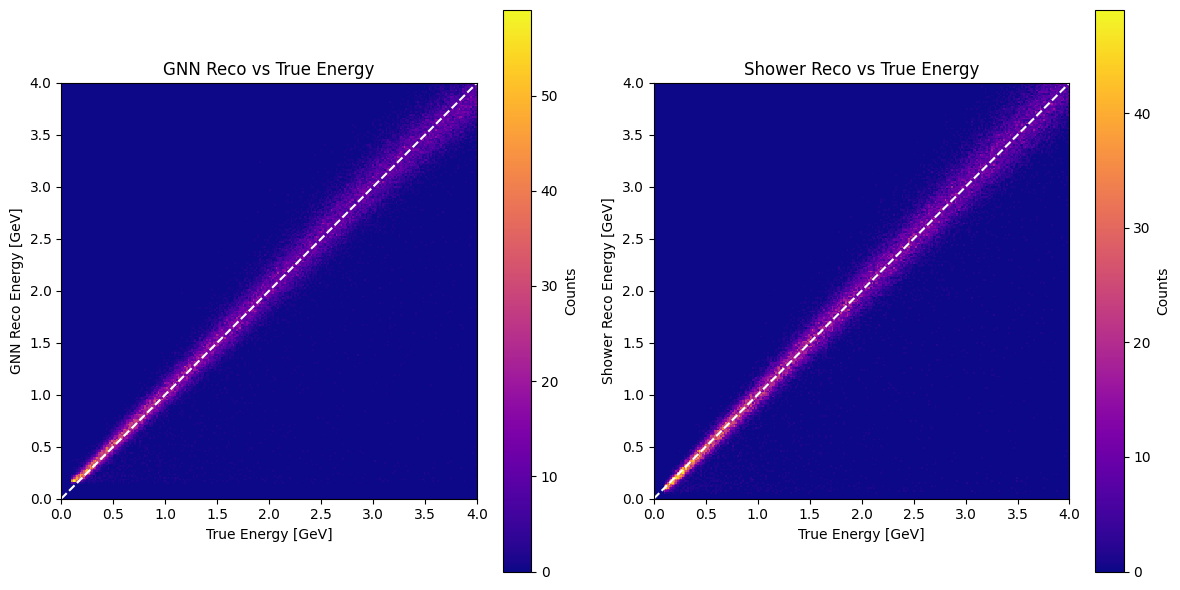

In [26]:
plot_reco_vs_true(true_E, pred_E, shower_reco_E=shower_reco_E)

### Residual histograms per thrown-energy bin

In [18]:
def relative_residual(y_true, y_pred):
    return (y_pred - y_true) / np.clip(y_true, 1e-12, None)

def plot_residuals_per_energy_bin(y_true, y_pred, title, nbins=16, xrange=(-1, 1)):
    edges = np.linspace(y_true.min(), y_true.max(), nbins + 1)
    ncols = 5
    nrows = int(np.ceil(nbins / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows))
    axes = np.atleast_1d(axes).ravel()

    resid = relative_residual(y_true, y_pred)

    for i in range(nbins):
        ax = axes[i]
        lo, hi = edges[i], edges[i + 1]
        mask = (y_true >= lo) & (y_true < hi)

        r = resid[mask]
        if len(r) == 0:
            ax.axis("off")
            continue

        mu = np.mean(r)
        sigma = np.std(r)

        ax.hist(r, bins=30, range=xrange, alpha=0.8)
        ax.set_title(f"{lo:.2f}-{hi:.2f} GeV\nμ={mu:+.3f} σ={sigma:.3f}", fontsize=8)
        ax.set_xlim(*xrange)
        ax.tick_params(labelsize=7)

    for j in range(nbins, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()

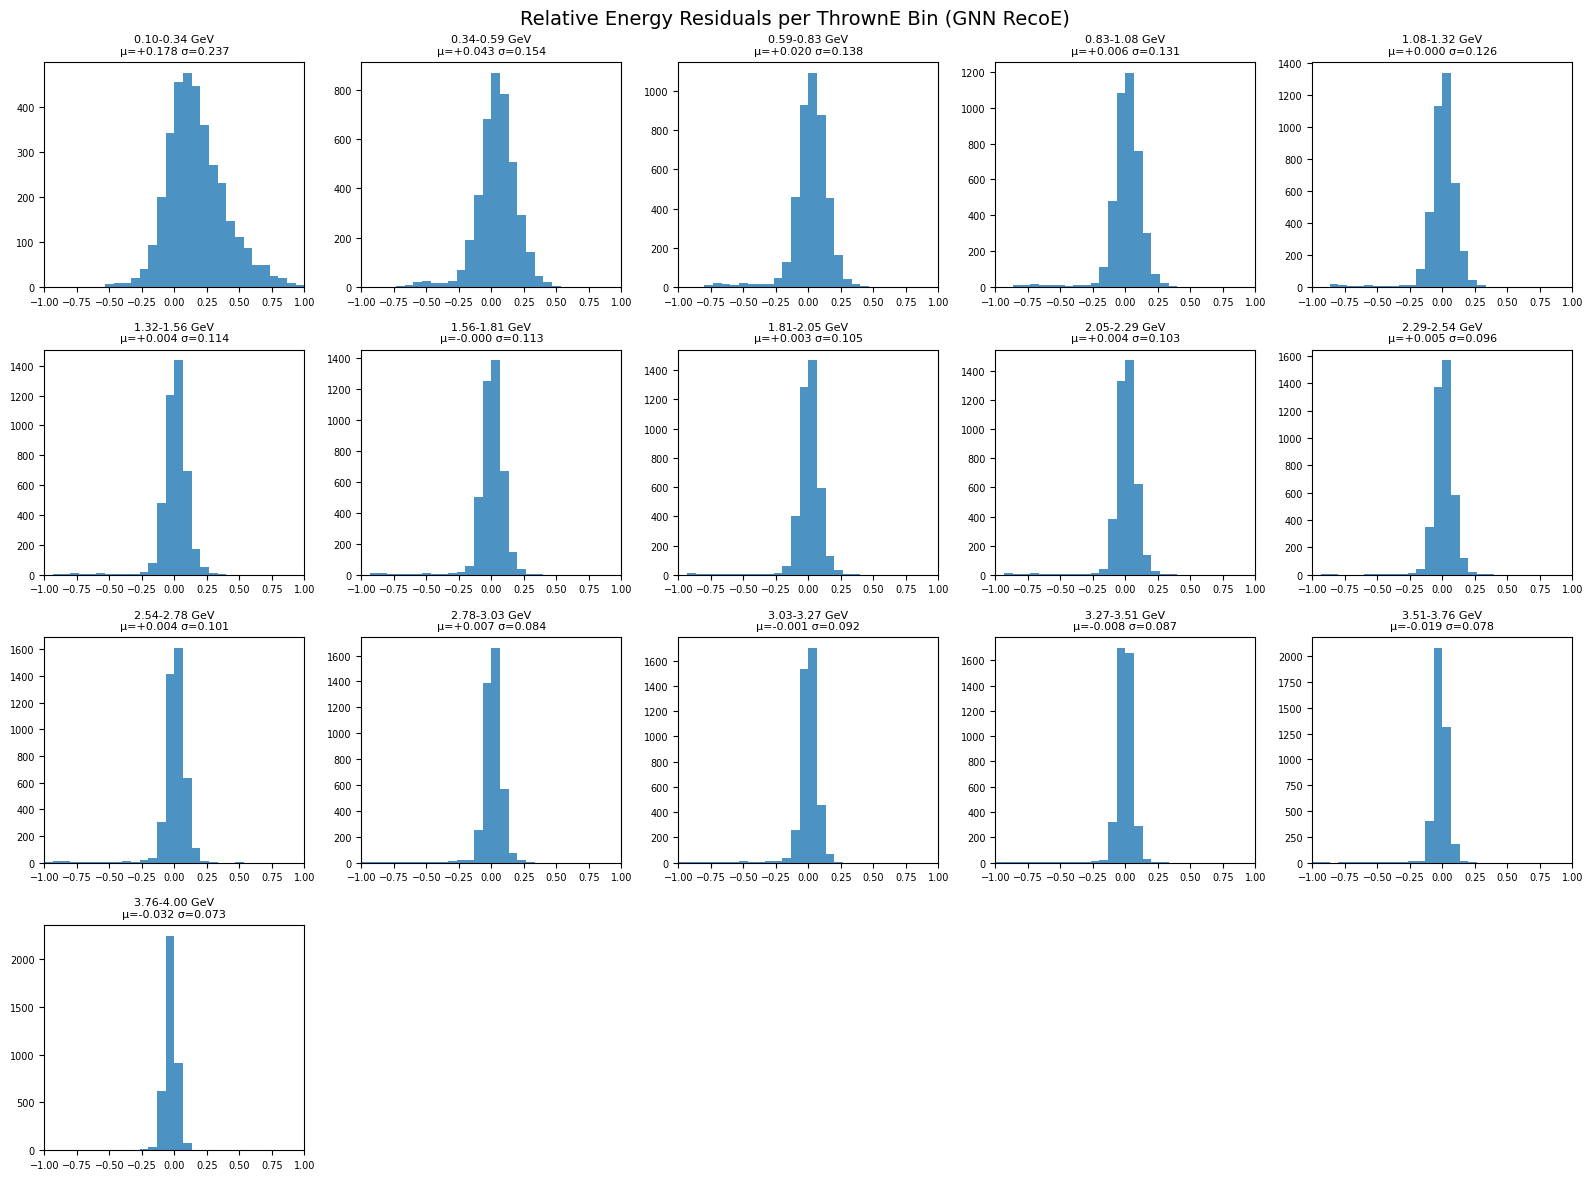

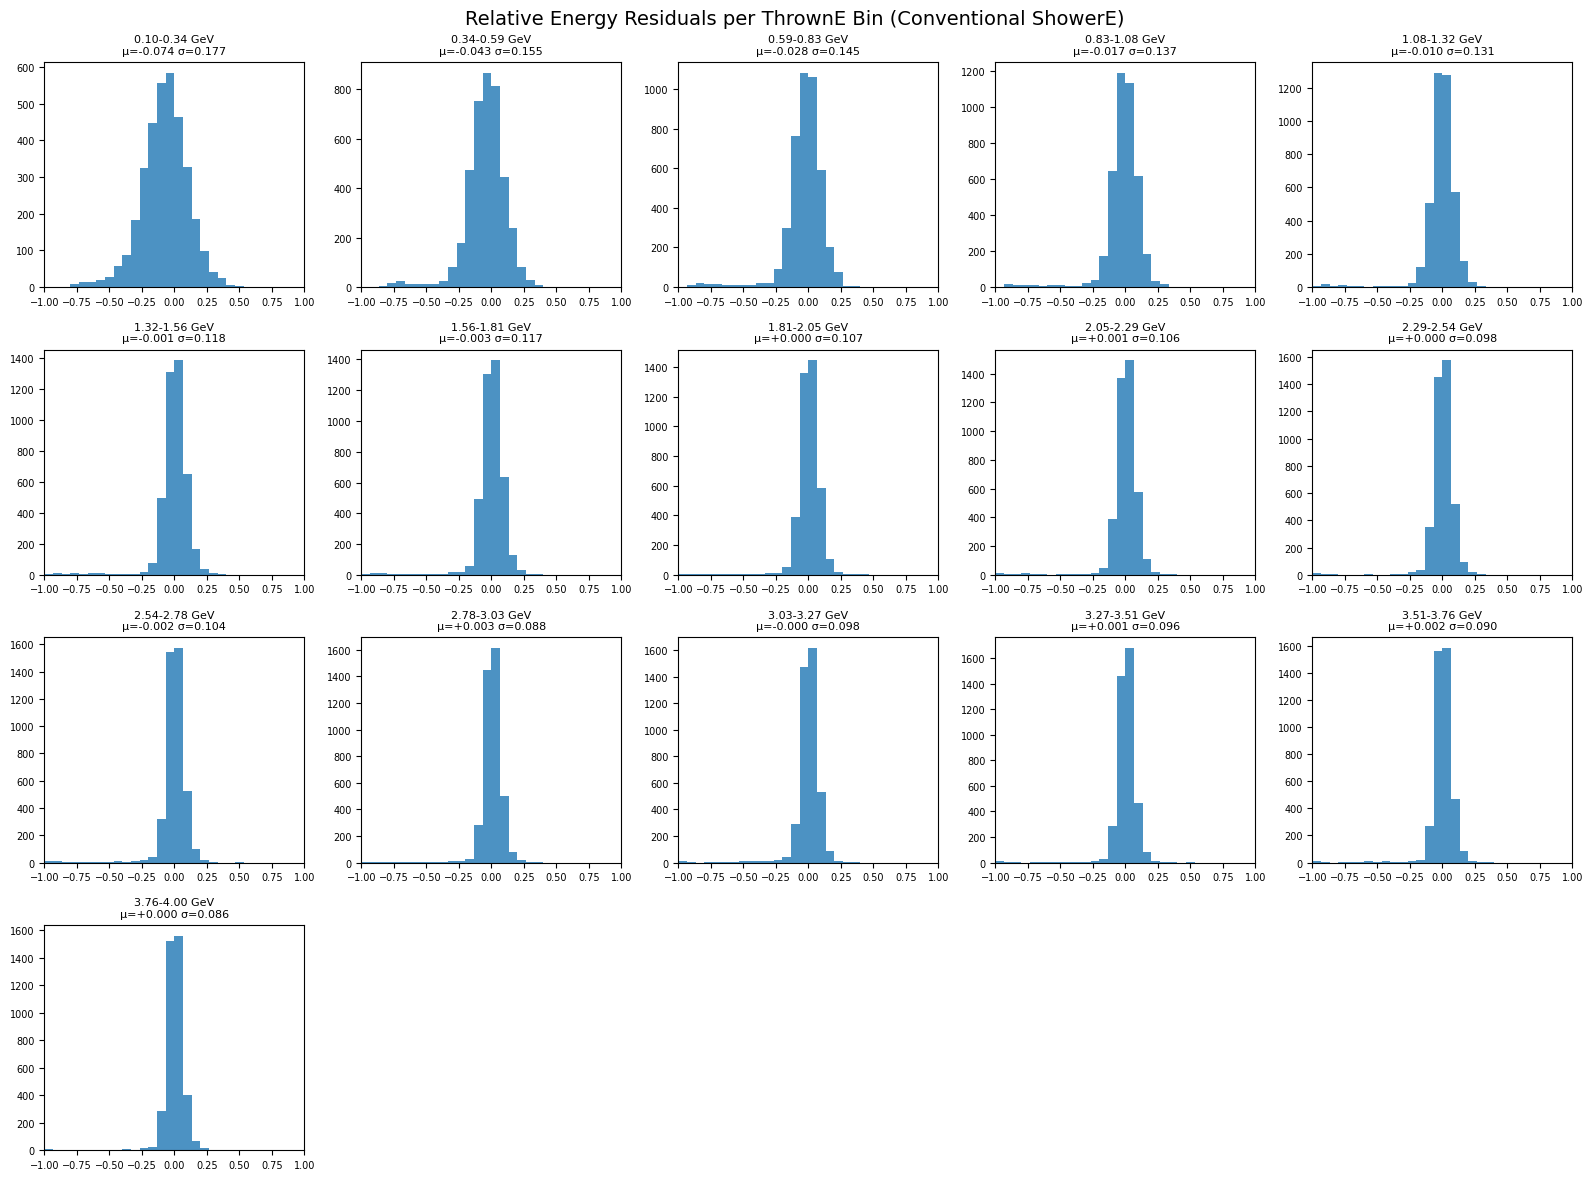

In [21]:
plot_residuals_per_energy_bin(
    true_E,
    pred_E,
    title="Relative Energy Residuals per ThrownE Bin (GNN RecoE)"
)

plot_residuals_per_energy_bin(
    true_E,
    shower_reco_E,
    title="Relative Energy Residuals per ThrownE Bin (Conventional ShowerE)"
)

### Energy resolution vs true energy

In [19]:
def compute_resolution_vs_energy(y_true, y_pred, nbins=16):
    edges = np.linspace(y_true.min(), y_true.max(), nbins + 1)
    centers, sigmas, sigma_errs = [], [], []

    resid = relative_residual(y_true, y_pred)

    for i in range(nbins):
        lo, hi = edges[i], edges[i + 1]
        mask = (y_true >= lo) & (y_true < hi)

        r = resid[mask]
        t = y_true[mask]

        if len(r) < 10:
            continue

        sigma = np.std(r)
        sigma_err = sigma / np.sqrt(2 * (len(r) - 1))

        centers.append(np.mean(t))
        sigmas.append(sigma)
        sigma_errs.append(sigma_err)

    return np.array(centers), np.array(sigmas), np.array(sigma_errs)

def plot_resolution_comparison(true_E, pred_E, shower_reco_E, nbins=16):
    c1, s1, e1 = compute_resolution_vs_energy(true_E, pred_E, nbins=nbins)
    c2, s2, e2 = compute_resolution_vs_energy(true_E, shower_reco_E, nbins=nbins)

    plt.figure(figsize=(8, 6))
    plt.errorbar(c1, s1, yerr=e1, marker="o", capsize=3, label="GNN RecoE")
    plt.errorbar(c2, s2, yerr=e2, marker="s", capsize=3, label="Conventional ShowerE")

    plt.xlabel("Thrown Energy [GeV]")
    plt.ylabel(r"$\sigma[(E_{\mathrm{reco}}-E_{\mathrm{true}})/E_{\mathrm{true}}]$")
    plt.title("Energy Resolution vs Thrown Energy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

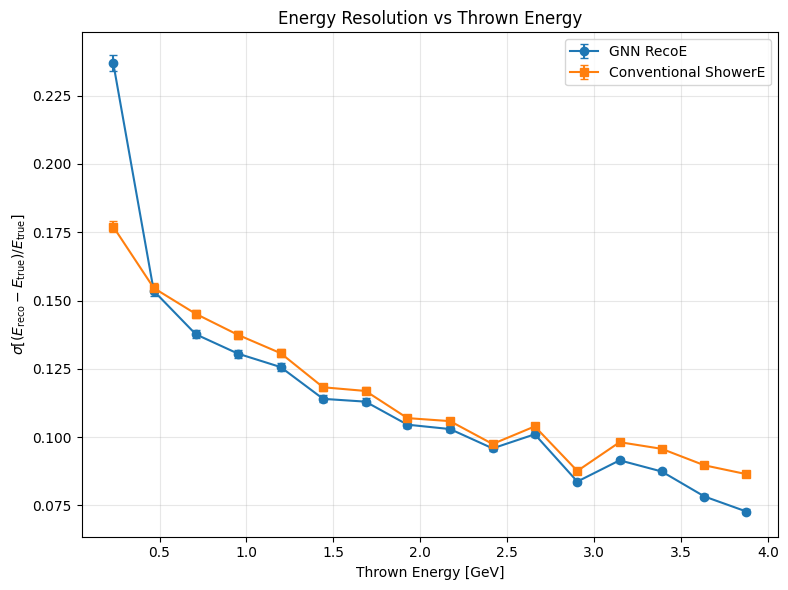

In [22]:
plot_resolution_comparison(true_E, pred_E, shower_reco_E, nbins=16)